In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_s_curve

from Autoencoders import IsometricAutoencoder
from IsotropicAutoencoder.helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler

random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
    
    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    
    def forward(self, z):
        return self.fc(z)

In [3]:
def make_halve_sphere(n_samples=1000, noise=0.1, random_state=None):
    """
    Generate a half-sphere dataset.
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    # Generate random points on a sphere
    phi = np.random.uniform(0, np.pi, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    
    # Keep only the upper hemisphere
    mask = z >= 0
    x = x[mask]
    y = y[mask]
    z = z[mask]
    
    # Add noise
    noise_x = np.random.normal(0, noise, x.shape)
    noise_y = np.random.normal(0, noise, y.shape)
    noise_z = np.random.normal(0, noise, z.shape)
    
    x += noise_x
    y += noise_y
    z += noise_z

    labels = z
    
    return np.column_stack((x, y, z)), labels

In [4]:
data, labels = make_halve_sphere(n_samples=2000, noise=0.05, random_state=random_state)
data = torch.tensor(data, dtype=torch.float32).to(device)
val_data, val_labels = make_halve_sphere(n_samples=1000, noise=0.05, random_state=random_state+1)
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)

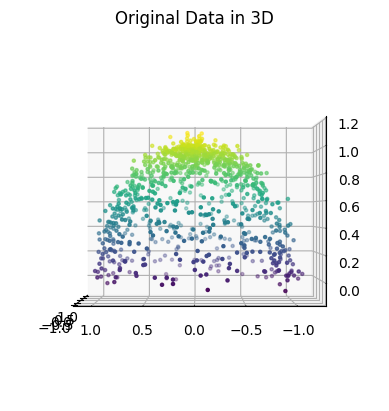

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0].cpu(), data[:, 1].cpu(), data[:, 2].cpu(), c=labels, s=5)
ax.set_title("Original Data in 3D")
ax.view_init(0, 180, 0)
plt.show()

In [6]:
# define model parameters
latent_dim = 2
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 64

model_path = "models/isometric_autoencoder_halve_sphere.pth"
optimizer_path = "models/isometric_autoencoder_halve_sphere_optimizer.pth"

In [7]:
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
isometric_autoencoder = IsometricAutoencoder(encoder, decoder, lambda_iso=0.1).to(device)
optmizer, scheduler = isometric_autoencoder.train_model(data=data, val_data=val_data, batch_size=batch_size, epochs=1000, learning_rate=0.001, log_every=100, val_every=100)

/home/maxheise/anaconda3/envs/ML/lib/python3.13/site-packages/torch/autograd/graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch [100/1000], Loss: 0.00218173, Reconstruction Loss: 0.00116709, Isometric Loss: 0.01014636
Epoch [100/1000], Validation Loss: 0.00233729, Reconstruction Loss: 0.00141066, Isometric Loss: 0.00926633
Epoch [200/1000], Loss: 0.00205872, Reconstruction Loss: 0.00105183, Isometric Loss: 0.01006887
Epoch [200/1000], Validation Loss: 0.00243234, Reconstruction Loss: 0.00125130, Isometric Loss: 0.01181044
Epoch [300/1000], Loss: 0.00203764, Reconstruction Loss: 0.00101428, Isometric Loss: 0.01023358
Epoch [300/1000], Validation Loss: 0.00253006, Reconstruction Loss: 0.00124437, Isometric Loss: 0.01285688
Epoch [400/1000], Loss: 0.00200232, Reconstruction Loss: 0.00100645, Isometric Loss: 0.00995877
Epoch [400/1000], Validation Loss: 0.00247081, Reconstruction Loss: 0.00124335, Isometric Loss: 0.01227460
Epoch [500/1000], Loss: 0.00199425, Reconstruction Loss: 0.00100909, Isometric Loss: 0.00985152
Epoch [500/1000], Validation Loss: 0.00227849, Reconstruction Loss: 0.00124314, Isometric Lo

In [8]:
isometric_autoencoder.save_checkpoint(model_path)
save_optimizer_and_scheduler(optimizer_path, optmizer, scheduler)

Checkpoint saved to models/isometric_autoencoder_halve_sphere.pth at epoch 1001
Optimizer and scheduler saved to models/isometric_autoencoder_halve_sphere_optimizer.pth


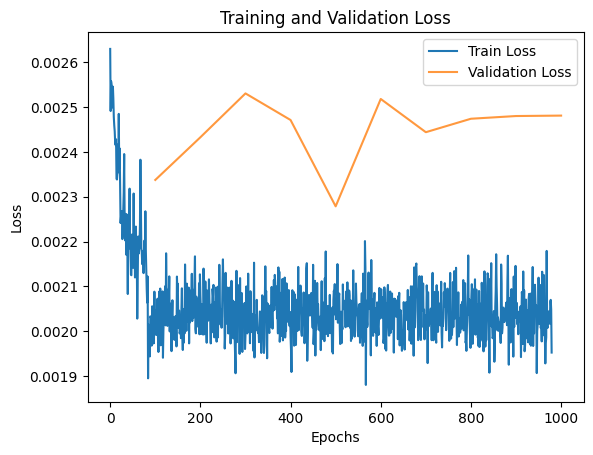

In [9]:
plt.plot(isometric_autoencoder.loss_list[20:], label='Train Loss')
plt.plot(np.linspace(100, 1000, 10), isometric_autoencoder.val_loss_list, alpha=0.8, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

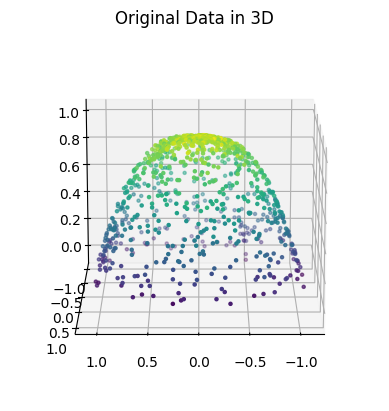

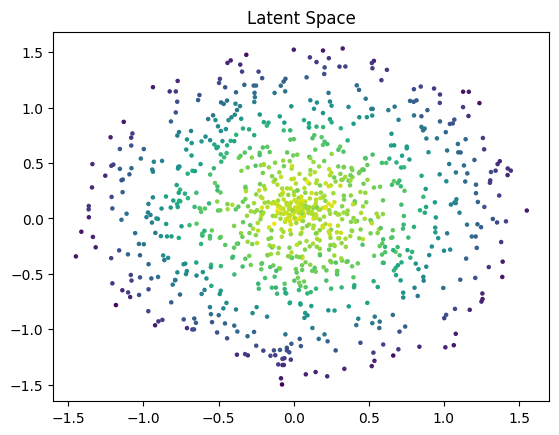

In [10]:
#Encode the data
encoded_data = isometric_autoencoder.encode(data)
# Decode the data
decoded_data = isometric_autoencoder.decode(encoded_data).cpu().detach()
encoded_data = encoded_data.cpu().detach()

# Visualize the reconstruction
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(decoded_data[:, 0], decoded_data[:, 1], decoded_data[:, 2], c=labels, cmap='viridis', s=5)
ax.set_title("Original Data in 3D")
ax.view_init(15, 90, 0)
plt.show()
# Visualize the latent space
plt.scatter(encoded_data[:, 0], encoded_data[:, 1], c=labels, cmap='viridis', s=5)
plt.title("Latent Space")
plt.show()

In [11]:
num = 900
J = torch.zeros((num, 2, 2))
for i in range(num):
    latent = encoder(data[i:i+1])
    jac = torch.autograd.functional.jacobian(decoder, latent)
    jac = jac[0,:,0,:]
    J[i] = jac.T @ jac
print(J.mean(dim=0))
print(J.std(dim=0))

tensor([[ 0.9874, -0.0033],
        [-0.0033,  0.9761]])
tensor([[0.1847, 0.1276],
        [0.1276, 0.2065]])


In [12]:
# Load the model and optimizer from checkpoint
encoder = Encoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, output_dim=output_dim).to(device)
autoencoder = IsometricAutoencoder(encoder, decoder).load_model_from_checkpoint(model_path).to(device)
optimizer = autoencoder.get_default_optimizer()
scheduler = autoencoder.get_default_scheduler(optimizer)
optimizer, scheduler = load_optimizer_and_scheduler(optimizer_path, optimizer, scheduler)

Model and custom variables loaded from models/isometric_autoencoder_halve_sphere.pth
Optimizer and scheduler loaded from models/isometric_autoencoder_halve_sphere_optimizer.pth
